## Upload and Load the Dataset

In [2]:
from google.colab import files
uploaded = files.upload()

Saving heart Disease Data.csv to heart Disease Data.csv


In [3]:
import pandas as pd

df = pd.read_csv("heart Disease Data.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


# Adding Column Names

In [4]:
columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df.columns = columns
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


# Basic Dataset Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       66 non-null     float64
 1   sex       66 non-null     float64
 2   cp        66 non-null     float64
 3   trestbps  66 non-null     float64
 4   chol      66 non-null     float64
 5   fbs       66 non-null     float64
 6   restecg   66 non-null     float64
 7   thalach   66 non-null     float64
 8   exang     66 non-null     float64
 9   oldpeak   66 non-null     float64
 10  slope     66 non-null     float64
 11  ca        66 non-null     float64
 12  thal      66 non-null     float64
 13  target    65 non-null     float64
dtypes: float64(14)
memory usage: 7.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,65.000000
mean,54.484848,0.727273,3.075758,132.363636,244.651515,0.166667,0.969697,151.363636,0.333333,1.259091,1.651515,0.590909,4.757576,0.876923
std,8.248529,0.448775,1.012394,14.185189,50.763552,0.375534,1.007200,20.656633,0.475017,0.958200,0.712362,0.876659,1.953778,1.243831
min,37.000000,0.000000,1.000000,105.000000,167.000000,0.000000,0.000000,108.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,49.250000,0.000000,2.250000,120.000000,211.250000,0.000000,0.000000,139.250000,0.000000,0.500000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,233.500000,0.000000,0.000000,157.000000,0.000000,1.200000,2.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,274.500000,0.000000,2.000000,167.250000,1.000000,1.800000,2.000000,1.000000,7.000000,1.000000
max,71.000000,1.000000,4.000000,172.000000,417.000000,1.000000,2.000000,188.000000,1.000000,3.600000,3.000000,3.000000,7.000000,4.000000


# Check class distribution:

In [7]:
df["target"].value_counts()

,count
target,
0.0,37
1.0,12
2.0,7
3.0,5
4.0,4


# Prepare Data for Clustering

In [8]:
from sklearn.preprocessing import StandardScaler

features = ["age","chol","trestbps","thalach"]

X_cluster = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Run K-Means Clustering

In [9]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cluster
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0,2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,1


## Check cluster counts:

In [10]:
df["cluster"].value_counts()

,count
cluster,
2,28
1,21
0,17


# Visualize Clusters

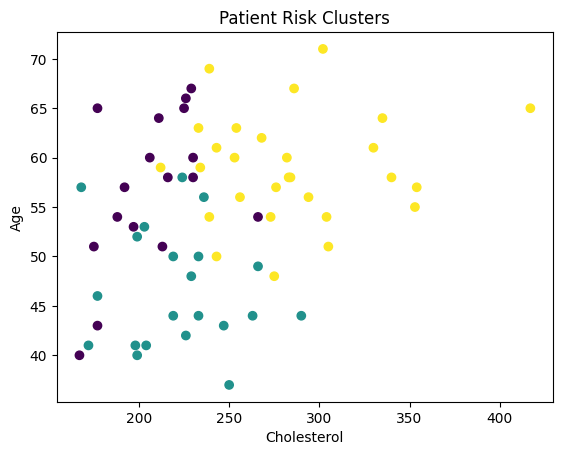

In [11]:
import matplotlib.pyplot as plt

plt.scatter(df["chol"], df["age"], c=df["cluster"])
plt.xlabel("Cholesterol")
plt.ylabel("Age")
plt.title("Patient Risk Clusters")
plt.show()

# Prepare Data for Supervised Learning

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression Model

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

# Make Predictions

In [14]:
y_pred = model.predict(X_test)

# Evaluate Model Performance

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Create a boolean mask for non-NaN values in y_test
non_nan_mask = ~y_test.isna()

# Filter y_test and y_pred to exclude NaN values
y_test_filtered = y_test[non_nan_mask]
y_pred_filtered = y_pred[non_nan_mask.values] # .values ensures correct indexing for numpy array

print("Accuracy:", accuracy_score(y_test_filtered, y_pred_filtered))

Accuracy: 0.46153846153846156


# Confusion Matrix

In [16]:
confusion_matrix(y_test_filtered, y_pred_filtered)

array([[5, 2, 0, 0, 0],
       [0, 1, 2, 1, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0]])

# Report

In [39]:
print(classification_report(y_test_filtered, y_pred_filtered, zero_division=0))

              precision    recall  f1-score   support

         0.0       1.00      0.71      0.83         7
         1.0       0.20      0.25      0.22         4
         2.0       0.00      0.00      0.00         1
         3.0       0.00      0.00      0.00         0
         4.0       0.00      0.00      0.00         1

    accuracy                           0.46        13
   macro avg       0.24      0.19      0.21        13
weighted avg       0.60      0.46      0.52        13



# Feature Importance

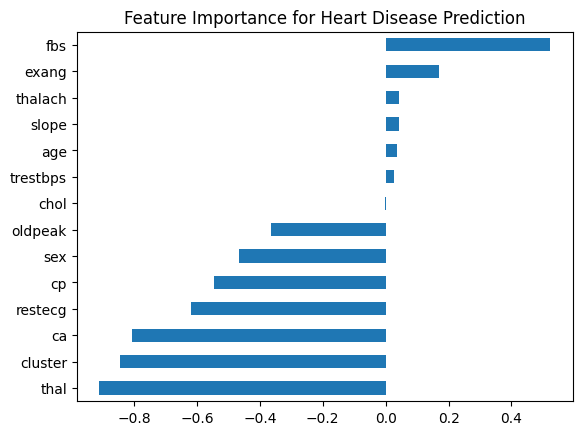

In [18]:
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance for Heart Disease Prediction")
plt.show()

## Check for Missing Values

In [19]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [20]:
df = df.replace("?", pd.NA)
df = df.dropna()

# Convert everything to numeric:

In [21]:
df = df.apply(pd.to_numeric)

# Correlation Analysis

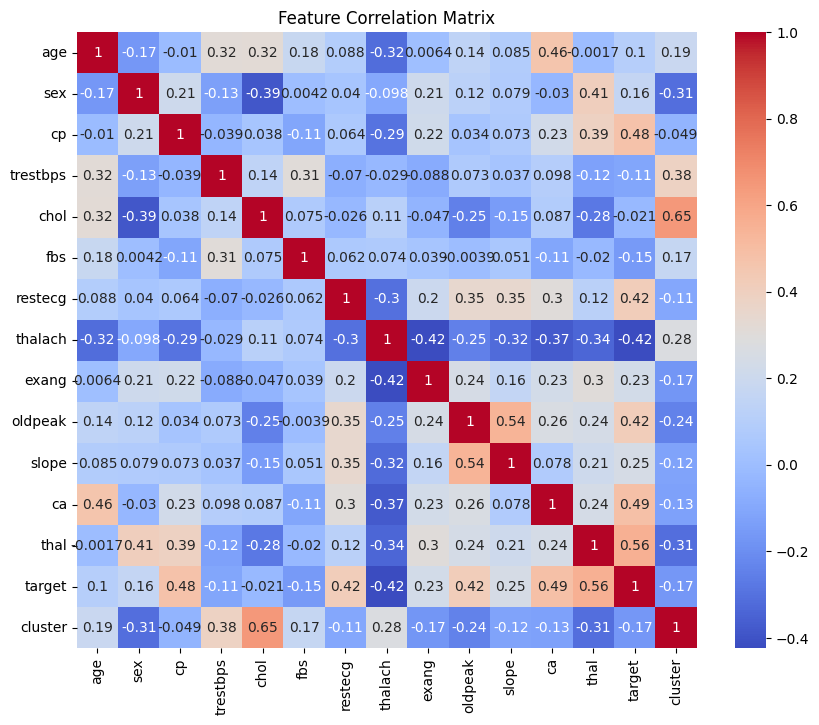

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

# Distribution of Heart Disease

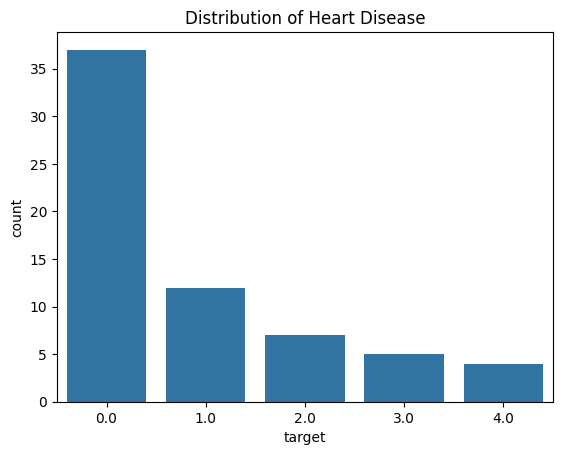

In [23]:
sns.countplot(x="target", data=df)
plt.title("Distribution of Heart Disease")
plt.show()

# Feature Scaling

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop("target", axis=1))

# Determining Optimal Clusters using Elbow Method

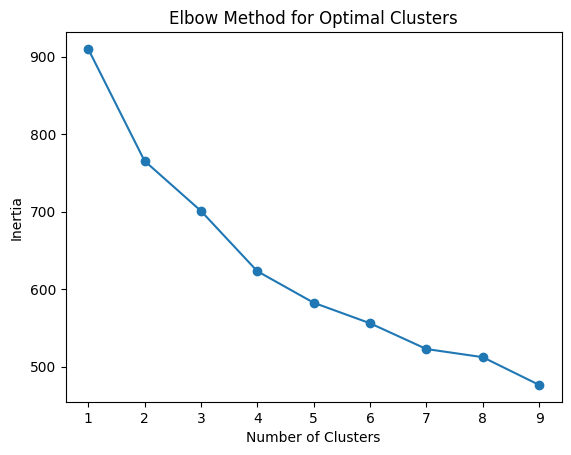

In [25]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# Apply K-Means Clustering

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cluster
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0,2
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0,0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,1
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,1


# Check cluster distribution:

In [27]:
df["cluster"].value_counts()

,count
cluster,
1,35
0,19
2,11


# Visualize Clusters

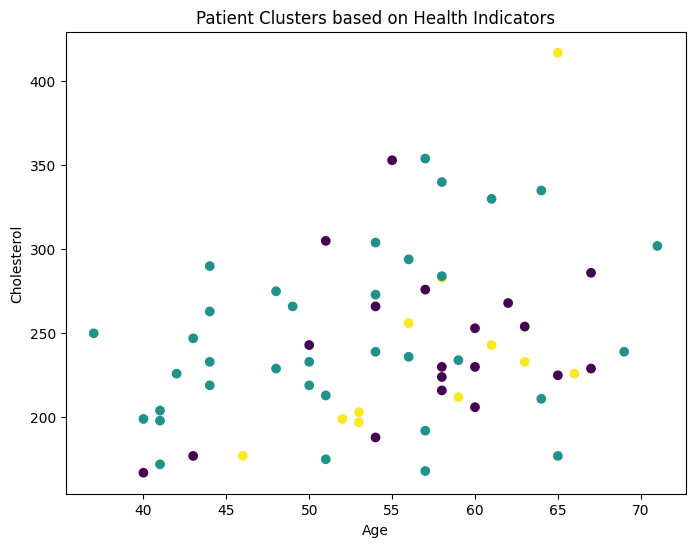

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(df["age"], df["chol"], c=df["cluster"], cmap="viridis")

plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.title("Patient Clusters based on Health Indicators")

plt.show()

# Prepare Data for Prediction

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features for supervised learning
scaler_supervised = StandardScaler()
X_train_scaled = scaler_supervised.fit_transform(X_train)
X_test_scaled = scaler_supervised.transform(X_test)

# Logistic Regression Model

In [45]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

# Logistic Regression Evaluation

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log, zero_division=0))

Logistic Regression Accuracy: 0.5384615384615384
[[7 0 0 0 0]
 [2 0 0 0 0]
 [2 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 1 0]]
              precision    recall  f1-score   support

         0.0       0.64      1.00      0.78         7
         1.0       0.00      0.00      0.00         2
         2.0       0.00      0.00      0.00         3
         3.0       0.00      0.00      0.00         0
         4.0       0.00      0.00      0.00         1

    accuracy                           0.54        13
   macro avg       0.13      0.20      0.16        13
weighted avg       0.34      0.54      0.42        13



# Random Forest Model

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

# Random Forest Evaluation

In [48]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.5384615384615384
[[7 0 0 0 0]
 [2 0 0 0 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 0 0 0]]
              precision    recall  f1-score   support

         0.0       0.70      1.00      0.82         7
         1.0       0.00      0.00      0.00         2
         2.0       0.00      0.00      0.00         3
         3.0       0.00      0.00      0.00         0
         4.0       0.00      0.00      0.00         1

    accuracy                           0.54        13
   macro avg       0.14      0.20      0.16        13
weighted avg       0.38      0.54      0.44        13



# Comparing Models

In [49]:
log_acc = accuracy_score(y_test, y_pred_log)
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Logistic Regression:", log_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.5384615384615384
Random Forest: 0.5384615384615384


# ROC Curve

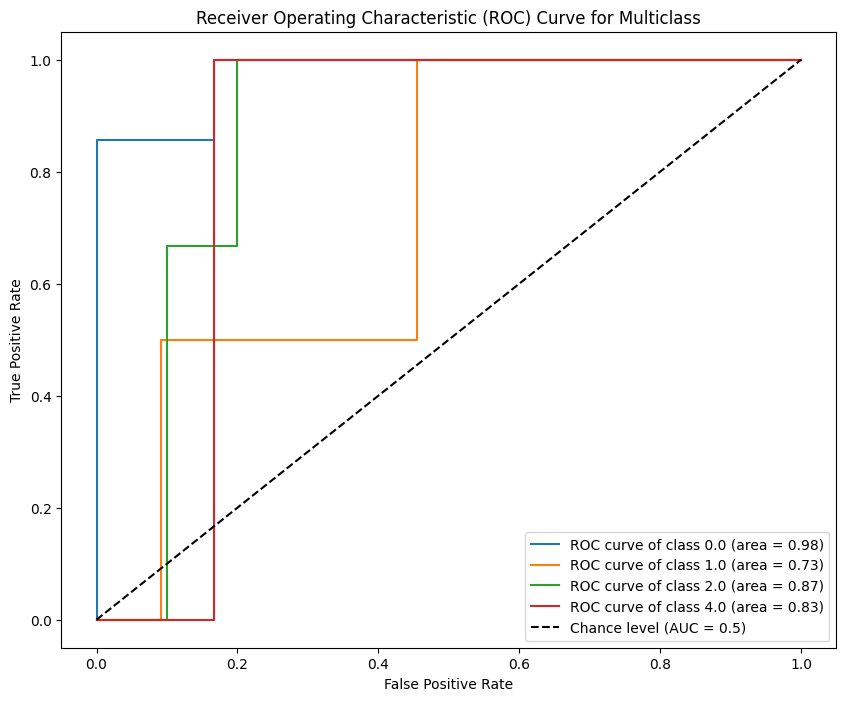

In [50]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get unique classes
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize the output for ROC curve
y_test_binarized = label_binarize(y_test, classes=classes)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Ensure predict_proba is called with scaled data
    y_prob_class = rf_model.predict_proba(X_test_scaled)[:, i]
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob_class)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {classes[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multiclass')
plt.legend(loc='lower right')
plt.show()

# Feature Importance

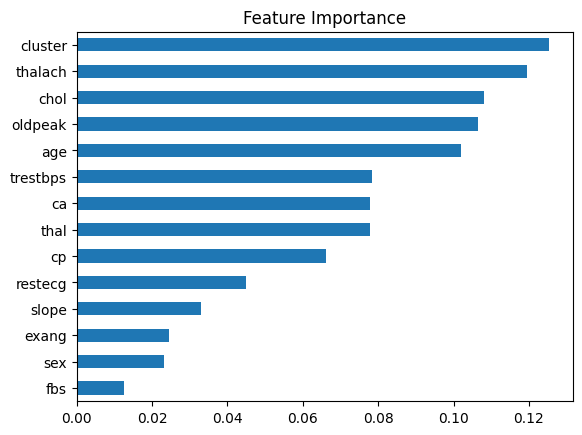

In [51]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

## Predict Heart Disease for a New Patient

In [52]:
sample_patient = X_test.iloc[0:1]

# Scale the sample patient data using the same scaler fitted on the training data
sample_patient_scaled = scaler_supervised.transform(sample_patient)

prediction = rf_model.predict(sample_patient_scaled)

print("Predicted Heart Disease Risk:", prediction)

Predicted Heart Disease Risk: [0.]


# In the dataset the target variable is binary:

Value	Meaning

0	No heart disease

1	Heart disease present